# 2107541 Machine Learning for Environmental Applications
## Lecture 5 : Data Preprocessing & Supervised Learning - Regression I
### Done By : 6730084521 Chatrphol Ovanonchai

## Step 1: Import the Dataset

In [140]:
## install library 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 

In [141]:
data = pd.read_csv("air_pollution_data.csv")

In [142]:
data.head()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Pressure (hPa),Precipitation (mm),Visibility (km),AQI,Season,City,Weather Condition
0,73.7,129.3,14.5,11.2,1.09,59.1,30.3,37.3,4.6,1004.1,2.1,9.3,101,Spring,Shanghai,Cloudy
1,171.6,231.9,64.8,17.5,2.35,50.2,11.0,43.2,5.2,998.0,5.5,6.5,228,Autumn,Beijing,Clear
2,134.4,195.9,49.5,15.5,1.77,63.5,22.5,89.3,1.7,1015.8,4.0,10.1,180,Spring,Shanghai,Cloudy
3,111.8,174.9,50.6,15.3,1.65,69.4,12.7,88.1,1.0,996.9,2.3,8.1,161,Autumn,Guangzhou,Rainy
4,36.5,49.3,26.2,5.1,0.67,94.2,16.3,35.3,0.6,1010.3,2.7,13.8,65,Autumn,Shanghai,Cloudy


## Step 2: Explore the Dataset

In [143]:
# Check size
print("Dataset Shape : " , data.shape)

Dataset Shape :  (150, 16)


In [144]:
# Check data types and missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PM2.5 (µg/m³)       150 non-null    float64
 1   PM10 (µg/m³)        150 non-null    float64
 2   NO2 (µg/m³)         150 non-null    float64
 3   SO2 (µg/m³)         150 non-null    float64
 4   CO (mg/m³)          150 non-null    float64
 5   O3 (µg/m³)          150 non-null    float64
 6   Temperature (°C)    150 non-null    float64
 7   Humidity (%)        150 non-null    float64
 8   Wind Speed (m/s)    150 non-null    float64
 9   Pressure (hPa)      150 non-null    float64
 10  Precipitation (mm)  150 non-null    float64
 11  Visibility (km)     150 non-null    float64
 12  AQI                 150 non-null    int64  
 13  Season              150 non-null    object 
 14  City                150 non-null    object 
 15  Weather Condition   150 non-null    object 
dtypes: float

In [145]:
# Check missing values
data.isnull().sum() ## no missing values 

PM2.5 (µg/m³)         0
PM10 (µg/m³)          0
NO2 (µg/m³)           0
SO2 (µg/m³)           0
CO (mg/m³)            0
O3 (µg/m³)            0
Temperature (°C)      0
Humidity (%)          0
Wind Speed (m/s)      0
Pressure (hPa)        0
Precipitation (mm)    0
Visibility (km)       0
AQI                   0
Season                0
City                  0
Weather Condition     0
dtype: int64

In [146]:
# Descriptive statistics
data.describe()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Pressure (hPa),Precipitation (mm),Visibility (km),AQI
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,90.388667,139.498667,40.829333,13.027333,1.336867,70.997333,22.646000,63.266667,3.223333,1010.048000,2.837333,11.002000,126.366667
std,50.408393,80.263385,21.646044,5.393768,0.627031,13.411329,7.663726,15.561265,1.633188,8.867872,2.938190,2.557197,69.933949
min,10.900000,15.000000,5.000000,1.000000,0.310000,39.400000,10.300000,35.300000,0.600000,995.300000,0.000000,5.200000,20.000000
25%,46.525000,72.175000,22.075000,8.750000,0.842500,62.025000,15.550000,50.250000,1.700000,1002.200000,0.900000,9.100000,70.000000
50%,86.150000,136.550000,40.600000,12.550000,1.290000,70.450000,22.900000,64.500000,3.300000,1010.350000,2.100000,11.300000,115.000000
75%,137.400000,207.325000,57.175000,17.500000,1.870000,80.475000,28.900000,74.475000,4.575000,1017.875000,3.975000,13.000000,191.750000
max,177.800000,300.000000,89.500000,25.800000,2.520000,104.500000,35.900000,90.000000,6.000000,1024.900000,19.200000,15.000000,269.000000


## Step 3: Define Feature `X` and Target `Y` 

In [147]:
# Feature

numeric_features = [
 "PM2.5 (µg/m³)",
 "PM10 (µg/m³)",
 "NO2 (µg/m³)",
 "SO2 (µg/m³)",
 "CO (mg/m³)",
 "O3 (µg/m³)",
 "Temperature (°C)",
 "Humidity (%)",
 "Wind Speed (m/s)",
 "Pressure (hPa)",
 "Precipitation (mm)",
 "Visibility (km)" ]

categorical_features = [
 "Season",
 "City",
 "Weather Condition"
]

X = data[numeric_features + categorical_features]

In [148]:
# Target
y = data["AQI"]

In [149]:
X.head()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Pressure (hPa),Precipitation (mm),Visibility (km),Season,City,Weather Condition
0,73.7,129.3,14.5,11.2,1.09,59.1,30.3,37.3,4.6,1004.1,2.1,9.3,Spring,Shanghai,Cloudy
1,171.6,231.9,64.8,17.5,2.35,50.2,11.0,43.2,5.2,998.0,5.5,6.5,Autumn,Beijing,Clear
2,134.4,195.9,49.5,15.5,1.77,63.5,22.5,89.3,1.7,1015.8,4.0,10.1,Spring,Shanghai,Cloudy
3,111.8,174.9,50.6,15.3,1.65,69.4,12.7,88.1,1.0,996.9,2.3,8.1,Autumn,Guangzhou,Rainy
4,36.5,49.3,26.2,5.1,0.67,94.2,16.3,35.3,0.6,1010.3,2.7,13.8,Autumn,Shanghai,Cloudy


In [150]:
y.head()

0    101
1    228
2    180
3    161
4     65
Name: AQI, dtype: int64

## Step 4: Train/Test Split 

In [151]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state=42) # osk142 diwaa

print("Training set size : " , X_train.shape)
print("Testing set size : " , X_test.shape)

Training set size :  (120, 15)
Testing set size :  (30, 15)


## Step 5: Column Transformer

In [152]:
## using one-hot encoder and column trainsformer 
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers= [  ("num", "passthrough", numeric_features) , # numerical data -> passthrough
                                                    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)  # categorical data -> use One-Hot encoder
                                               ] )

## Step 6: Pipeline and Model Training

In [153]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

## create Pipeline
model_pipeline = Pipeline([ # pipeline with list 
 ("preprocessing", preprocessor), # name , processor
 ("regression", LinearRegression()) # name , model
] , memory = None)

## steps : raw data -> preprocessor -> linear regression -> predicted value

In [154]:
## fit model with data 
model_pipeline.fit(X_train , y_train) ## call model_pipeline instead of LinReg

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['PM2.5 (µg/m³)',
                                                   'PM10 (µg/m³)',
                                                   'NO2 (µg/m³)', 'SO2 (µg/m³)',
                                                   'CO (mg/m³)', 'O3 (µg/m³)',
                                                   'Temperature (°C)',
                                                   'Humidity (%)',
                                                   'Wind Speed (m/s)',
                                                   'Pressure (hPa)',
                                                   'Precipitation (mm)',
                                                   'Visibility (km)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Season', 'City',
                                                   'Weather Condition'])])),
                ('regression', LinearRegression())])

## Step 7: Make Predictions

In [155]:
y_predicted = model_pipeline.predict(X_test)
y_predicted[:10] # call 10 first element 

array([202.4088482 , 107.40329006, 215.47730972, 111.76337095,
       207.85071723,  67.62859269,  87.85087156,  85.87900398,
        27.21091285,  72.36631857])

In [156]:
compared_df = pd.DataFrame({ 
                            "Actual AQI": y_test.values ,           
                            "Predicted AQI" : y_predicted  
                            })
compared_df[:10] # see only 10 first rows

,Actual AQI,Predicted AQI
0,199,202.408848
1,114,107.403290
2,245,215.477310
3,112,111.763371
4,197,207.850717
5,73,67.628593
6,81,87.850872
7,76,85.879004
8,44,27.210913
9,94,72.366319


## Step 8: Plot Actual vs Predicted AQI

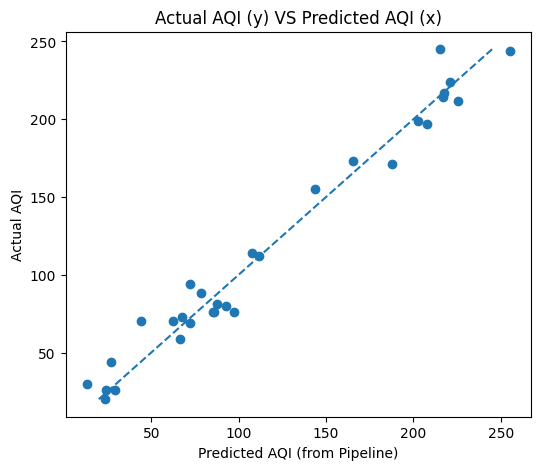

In [157]:
## using plt

## create figure
plt.figure(figsize = (6, 5))

## plot data (scatter plot)
plt.scatter(compared_df["Predicted AQI"] , compared_df["Actual AQI"])

## plot line (with min & max values)
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , linestyle = "--") ## (min,min) to (max,max)

## decorate graph 
plt.xlabel("Predicted AQI (from Pipeline)")
plt.ylabel("Actual AQI")
plt.title("Actual AQI (y) VS Predicted AQI (x)") 

plt.show() ## show graph 

## btw , It's not in the same as in lecture , But I think it doesn't affect the other parts (cuz I've done this cmds by myself)

## Step 9: Check Coefficient (β) and R^2

In [158]:
## call out feature names (inspect estimators with .named_steps)
feature_names = model_pipeline.named_steps["preprocessing"] ## call out like dict (by name that we done earlier)
feature_names = feature_names.get_feature_names_out() # got np array 

print("Number of features:", len(feature_names))
feature_names

Number of features: 23


array(['num__PM2.5 (µg/m³)', 'num__PM10 (µg/m³)', 'num__NO2 (µg/m³)',
       'num__SO2 (µg/m³)', 'num__CO (mg/m³)', 'num__O3 (µg/m³)',
       'num__Temperature (°C)', 'num__Humidity (%)',
       'num__Wind Speed (m/s)', 'num__Pressure (hPa)',
       'num__Precipitation (mm)', 'num__Visibility (km)',
       'cat__Season_Autumn', 'cat__Season_Spring', 'cat__Season_Summer',
       'cat__Season_Winter', 'cat__City_Beijing', 'cat__City_Guangzhou',
       'cat__City_Shanghai', 'cat__Weather Condition_Clear',
       'cat__Weather Condition_Cloudy', 'cat__Weather Condition_Hazy',
       'cat__Weather Condition_Rainy'], dtype=object)

In [159]:
## see coefficients in multiple linear regression (like calling model individually but we call via pipeline)
coefficients_arr = model_pipeline.named_steps["regression"].coef_ # array

coeff_df = pd.DataFrame( { 
                          "Feature Names" : feature_names , 
                          "Coefficient Values" : coefficients_arr
                          })
coeff_df.head() 

,Feature Names,Coefficient Values
0,num__PM2.5 (µg/m³),1.022918
1,num__PM10 (µg/m³),0.136449
2,num__NO2 (µg/m³),0.377948
3,num__SO2 (µg/m³),-0.609978
4,num__CO (mg/m³),3.756503


In [160]:
## intercepts
intercepts_val = model_pipeline.named_steps["regression"].intercept_ # array 
intercepts_val # have only 1 value 

np.float64(175.1542153291656)

In [161]:
## R^2 score
from sklearn.metrics import r2_score

r2_score_before_optimize = r2_score(y_true = y_test , y_pred = y_predicted)
print("R^2 score before optimize : " , round(r2_score_before_optimize , 4))

R^2 score before optimize :  0.9696


## Lab Activity: Build Your Own Multiple Linear Regression Model

### Task: Select a subset of environmental variables to predict AQI. Do not use all available variables.

[Click here for scoreboard](https://docs.google.com/spreadsheets/d/1cJ7lxcdpFzJuKfJE-ycs19KYpgbz9l6GeAKQ_YshKKs/edit?usp=sharing)

Note : How `permuation_importance` works
- [AI-Generated Web](https://claude.ai/artifact/Fxebo9rh3AxiwPoU5SzJfd)

- How I understand
1. Shuffle data with another row (each row) then check evaluation from model -> if it decrease much , it took more importance than the others
2. Find mean of importance score then will get feature importance by permutation

In [162]:
## check feature importance by these commands
# note that LinearRegression doesnt have feature_importances method , so I use permutation_importance instead

from sklearn.inspection import permutation_importance

result = permutation_importance(model_pipeline, X_test, y_test, n_repeats=67, random_state=42) # no need to change model 
## shuffle 10 times on every rows 

# Note : The highest mean score drop indicates the most important feature
most_important_idx = result.importances_mean.argmax() ## argmax() will get index of greatest value in array (note that we get mean value from N times)
most_important_feature_name = X_test.columns[most_important_idx] # normal index 

print("The most importance feature in data : " , most_important_feature_name)

The most importance feature in data :  PM2.5 (µg/m³)


In [163]:
# note : I'll use only 5 most important features 
important_features_sorted_ids = np.argsort(result.importances_mean)[::-1][:5]
    # np.atrgsort -> sort ascending order then reaturn array of order , so I need to reverse it
important_features_sorted_names = X_test.columns[important_features_sorted_ids] # normal index


## print out top-5 important features
print("Top 5 Most Importance Features")
for rank in range(len(important_features_sorted_names)) : 
    print(str(rank+ 1) + " --> " + important_features_sorted_names[rank])

Top 5 Most Importance Features
1 --> PM2.5 (µg/m³)
2 --> PM10 (µg/m³)
3 --> NO2 (µg/m³)
4 --> Wind Speed (m/s)
5 --> Pressure (hPa)


In [173]:
## calculate R^2 [AI-Assisted]

top5_features = important_features_sorted_names  # 5 อันดับแรกจาก permutation importance

num_sel = [f for f in numeric_features if f in top5_features]
cat_sel = [f for f in categorical_features if f in top5_features]

## create new transformer
transformers_top5 = []
if num_sel:
    transformers_top5.append(("num", "passthrough", num_sel))
if cat_sel:
    transformers_top5.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat_sel))

## do new preprocessor & pipeline
preprocessor_top5 = ColumnTransformer(transformers=transformers_top5)

pipeline_top5 = Pipeline([
    ("preprocessing", preprocessor_top5),
    ("regression", LinearRegression())
])

## fit ใหม่ด้วยแค่ 5 feature นี้ (train set)
pipeline_top5.fit(X_train[top5_features], y_train)

## predict บน test set (ที่ยังไม่ถูกแตะเลยตลอดขั้นตอนก่อนหน้า)
y_pred_top5 = pipeline_top5.predict(X_test[top5_features])

r2_top5 = r2_score(y_test, y_pred_top5)
print(f"R^2 using top 5 features: {r2_top5:.4f}")
print("Features used:", top5_features)

R^2 using top 5 features: 0.9816
Features used: Index(['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'Wind Speed (m/s)',
       'Pressure (hPa)'],
      dtype='object')


## Summary 
R^2 : 0.9816 

Feature Used : [PM2.5 PM10 NO2 WindSpeed Pressure]

## ----- Extra : These code below is how AI works to find how many feature to use to get most R^2 value (Re-read and revise by myself already) -----

### Idea: Use permutation importance ranking + cross-validation to pick the best number of features

1. Rank all raw features by `permutation_importance` mean score drop (already computed in `result` above)
2. Add features one by one, starting from the most important
3. For each subset size, refit a pipeline and measure R^2 with cross-validation (not just the single train/test split)
4. Plot CV-R^2 vs number of features -> pick the point where it stops improving (avoid overfitting)

In [165]:
## rank raw features from most -> least important, using the permutation_importance result computed earlier
ranked_idx = np.argsort(result.importances_mean)[::-1]
ranked_features = X_test.columns[ranked_idx].tolist()

print("Feature ranking (most -> least important):")
for rank, feat in enumerate(ranked_features, start=1):
    print(f"{rank}. {feat}")

Feature ranking (most -> least important):
1. PM2.5 (µg/m³)
2. PM10 (µg/m³)
3. NO2 (µg/m³)
4. Wind Speed (m/s)
5. Pressure (hPa)
6. SO2 (µg/m³)
7. CO (mg/m³)
8. Precipitation (mm)
9. O3 (µg/m³)
10. Humidity (%)
11. Visibility (km)
12. Temperature (°C)
13. City
14. Weather Condition
15. Season


In [166]:
## try adding features one by one (in ranked order) and measure R^2 with cross-validation
from sklearn.model_selection import cross_val_score

cv_scores_mean = []
cv_scores_std = []
n_features_list = list(range(1, len(ranked_features) + 1))

for k in n_features_list:
    selected = ranked_features[:k]
    num_sel = [f for f in numeric_features if f in selected]
    cat_sel = [f for f in categorical_features if f in selected]

    # only include a transformer if it actually has columns selected for this k
    transformers_k = []
    if num_sel:
        transformers_k.append(("num", "passthrough", num_sel))
    if cat_sel:
        transformers_k.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat_sel))

    preprocessor_k = ColumnTransformer(transformers=transformers_k)

    pipeline_k = Pipeline([
        ("preprocessing", preprocessor_k),
        ("regression", LinearRegression())
    ])

    scores = cross_val_score(pipeline_k, X_train[selected], y_train, cv=5, scoring="r2") # 5-Fold Cross Validation
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

    print(f"Top {k} feature(s) -> CV R^2 = {scores.mean():.4f} (+/- {scores.std():.4f})")

Top 1 feature(s) -> CV R^2 = 0.9636 (+/- 0.0157)
Top 2 feature(s) -> CV R^2 = 0.9650 (+/- 0.0152)
Top 3 feature(s) -> CV R^2 = 0.9678 (+/- 0.0176)
Top 4 feature(s) -> CV R^2 = 0.9679 (+/- 0.0189)
Top 5 feature(s) -> CV R^2 = 0.9678 (+/- 0.0191)
Top 6 feature(s) -> CV R^2 = 0.9681 (+/- 0.0190)
Top 7 feature(s) -> CV R^2 = 0.9667 (+/- 0.0202)
Top 8 feature(s) -> CV R^2 = 0.9696 (+/- 0.0180)
Top 9 feature(s) -> CV R^2 = 0.9685 (+/- 0.0177)
Top 10 feature(s) -> CV R^2 = 0.9681 (+/- 0.0173)
Top 11 feature(s) -> CV R^2 = 0.9666 (+/- 0.0174)
Top 12 feature(s) -> CV R^2 = 0.9661 (+/- 0.0180)
Top 13 feature(s) -> CV R^2 = 0.9657 (+/- 0.0173)
Top 14 feature(s) -> CV R^2 = 0.9627 (+/- 0.0171)
Top 15 feature(s) -> CV R^2 = 0.9629 (+/- 0.0194)


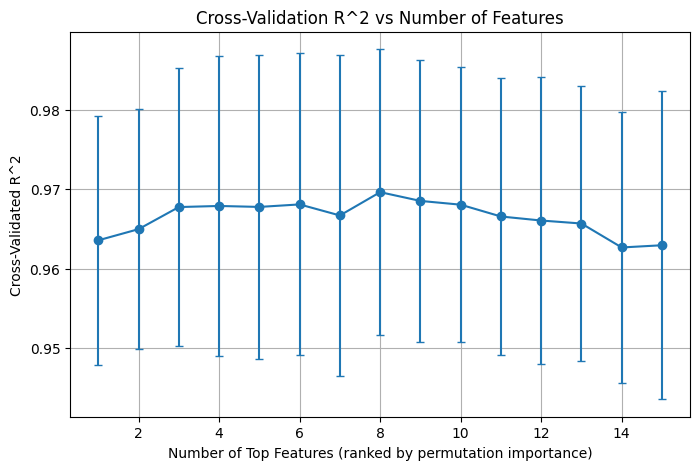

Best number of features: 8, CV R^2 = 0.9696
Selected features: ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'Wind Speed (m/s)', 'Pressure (hPa)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Precipitation (mm)']


In [167]:
## plot CV R^2 vs number of features to visually find the point where it stops improving
plt.figure(figsize=(8, 5))
plt.errorbar(n_features_list, cv_scores_mean, yerr=cv_scores_std, marker="o", capsize=3)
plt.xlabel("Number of Top Features (ranked by permutation importance)")
plt.ylabel("Cross-Validated R^2")
plt.title("Cross-Validation R^2 vs Number of Features")
plt.grid(True)
plt.show()

best_k = n_features_list[int(np.argmax(cv_scores_mean))]
print(f"Best number of features: {best_k}, CV R^2 = {max(cv_scores_mean):.4f}")
print("Selected features:", ranked_features[:best_k])

## Other methods to select the number/subset of features

- **Method 2: RFECV** — recursively drop the least important feature, re-fit, and use cross-validation to find the optimal count automatically
- **Method 3: Sequential Forward Selection** — start from 0 features, greedily add the one that improves CV score the most at each step
- **Method 4: LassoCV** — regularization that shrinks unimportant coefficients to exactly 0 (built-in feature selection)
- **Method 5: Adjusted R^2** — penalizes R^2 for adding more features, so we can compare subset sizes without running cross-validation

All of methods 2-4 need a numeric feature matrix (categorical columns already one-hot encoded), so we reuse the already-fitted `preprocessor` from the pipeline to transform `X_train`/`X_test` once below.

In [168]:
## build one shared, already-encoded feature matrix (numeric + one-hot) for methods 2-4
import scipy.sparse as sp

X_train_enc = preprocessor.transform(X_train)
X_test_enc = preprocessor.transform(X_test)

if sp.issparse(X_train_enc):
    X_train_enc = X_train_enc.toarray()
    X_test_enc = X_test_enc.toarray()

encoded_feature_names = preprocessor.get_feature_names_out()

X_train_enc_df = pd.DataFrame(X_train_enc, columns=encoded_feature_names, index=X_train.index)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=encoded_feature_names, index=X_test.index)

X_train_enc_df.head()

,num__PM2.5 (µg/m³),num__PM10 (µg/m³),num__NO2 (µg/m³),num__SO2 (µg/m³),num__CO (mg/m³),num__O3 (µg/m³),num__Temperature (°C),num__Humidity (%),num__Wind Speed (m/s),num__Pressure (hPa),...,cat__Season_Spring,cat__Season_Summer,cat__Season_Winter,cat__City_Beijing,cat__City_Guangzhou,cat__City_Shanghai,cat__Weather Condition_Clear,cat__Weather Condition_Cloudy,cat__Weather Condition_Hazy,cat__Weather Condition_Rainy
22,59.7,79.2,26.4,11.0,0.84,89.9,30.8,82.7,4.5,1007.5,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
15,41.2,65.2,38.0,7.5,0.64,104.5,19.1,73.8,2.7,1000.8,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
65,102.3,143.6,36.4,11.3,1.42,69.5,27.7,73.3,1.3,1013.4,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
11,174.9,286.4,89.5,25.8,2.40,63.6,10.3,71.7,3.2,1007.8,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
42,15.8,19.8,22.0,8.1,0.45,77.7,21.8,90.0,2.3,999.5,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


### Method 2: RFECV (Recursive Feature Elimination with Cross-Validation)

Optimal number of features (RFECV): 19
Selected features: ['num__PM2.5 (µg/m³)', 'num__PM10 (µg/m³)', 'num__NO2 (µg/m³)', 'num__SO2 (µg/m³)', 'num__CO (mg/m³)', 'num__Wind Speed (m/s)', 'num__Pressure (hPa)', 'num__Precipitation (mm)', 'cat__Season_Autumn', 'cat__Season_Spring', 'cat__Season_Summer', 'cat__Season_Winter', 'cat__City_Beijing', 'cat__City_Guangzhou', 'cat__City_Shanghai', 'cat__Weather Condition_Clear', 'cat__Weather Condition_Cloudy', 'cat__Weather Condition_Hazy', 'cat__Weather Condition_Rainy']


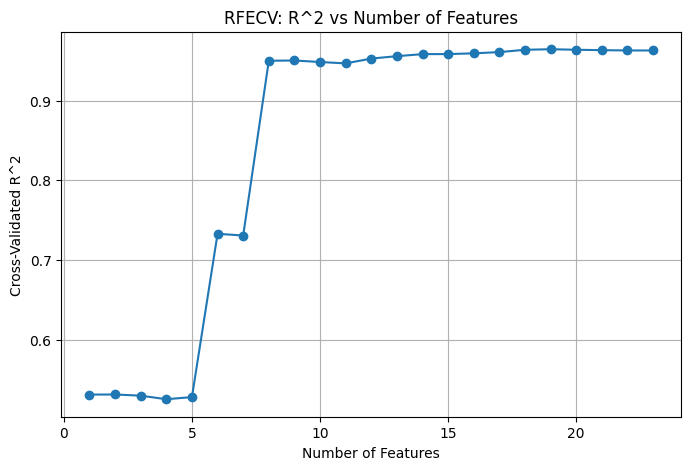

In [169]:
from sklearn.feature_selection import RFECV

rfecv = RFECV(estimator=LinearRegression(), step=1, cv=5, scoring="r2")
rfecv.fit(X_train_enc_df, y_train)

print("Optimal number of features (RFECV):", rfecv.n_features_)
print("Selected features:", X_train_enc_df.columns[rfecv.support_].tolist())

## rfecv.cv_results_ requires scikit-learn >= 1.0; use rfecv.grid_scores_ on older versions
mean_scores = rfecv.cv_results_["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mean_scores) + 1), mean_scores, marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validated R^2")
plt.title("RFECV: R^2 vs Number of Features")
plt.grid(True)
plt.show()

### Method 3: Sequential Forward Selection

Search limited to the first 10 feature counts to keep runtime reasonable (forward selection re-fits many models per step).

k=1: CV R^2 = 0.9636, features = ['num__PM2.5 (µg/m³)']
k=2: CV R^2 = 0.9664, features = ['num__PM2.5 (µg/m³)', 'num__NO2 (µg/m³)']
k=3: CV R^2 = 0.9691, features = ['num__PM2.5 (µg/m³)', 'num__NO2 (µg/m³)', 'num__Precipitation (mm)']
k=4: CV R^2 = 0.9698, features = ['num__PM2.5 (µg/m³)', 'num__PM10 (µg/m³)', 'num__NO2 (µg/m³)', 'num__Precipitation (mm)']
k=5: CV R^2 = 0.9705, features = ['num__PM2.5 (µg/m³)', 'num__PM10 (µg/m³)', 'num__NO2 (µg/m³)', 'num__SO2 (µg/m³)', 'num__Precipitation (mm)']
k=6: CV R^2 = 0.9711, features = ['num__PM2.5 (µg/m³)', 'num__PM10 (µg/m³)', 'num__NO2 (µg/m³)', 'num__SO2 (µg/m³)', 'num__Precipitation (mm)', 'cat__Season_Autumn']
k=7: CV R^2 = 0.9713, features = ['num__PM2.5 (µg/m³)', 'num__PM10 (µg/m³)', 'num__NO2 (µg/m³)', 'num__SO2 (µg/m³)', 'num__Precipitation (mm)', 'cat__Season_Autumn', 'cat__City_Shanghai']
k=8: CV R^2 = 0.9714, features = ['num__PM2.5 (µg/m³)', 'num__PM10 (µg/m³)', 'num__NO2 (µg/m³)', 'num__SO2 (µg/m³)', 'num__Pressure (hPa)', 'nu

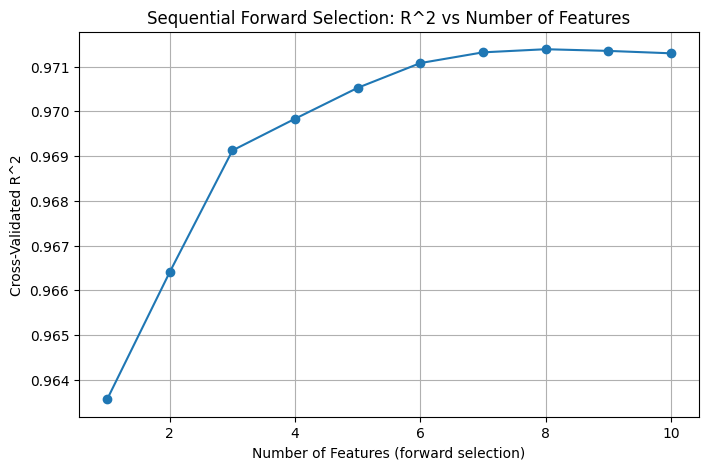

In [170]:
from sklearn.feature_selection import SequentialFeatureSelector

sfs_scores = []
max_k = min(10, X_train_enc_df.shape[1])
k_range = range(1, max_k + 1)

for k in k_range:
    sfs = SequentialFeatureSelector(
        LinearRegression(), n_features_to_select=k, direction="forward", cv=5, scoring="r2"
    )
    sfs.fit(X_train_enc_df, y_train)
    selected_cols = X_train_enc_df.columns[sfs.get_support()]

    score = cross_val_score(LinearRegression(), X_train_enc_df[selected_cols], y_train, cv=5, scoring="r2").mean()
    sfs_scores.append(score)
    print(f"k={k}: CV R^2 = {score:.4f}, features = {list(selected_cols)}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), sfs_scores, marker="o")
plt.xlabel("Number of Features (forward selection)")
plt.ylabel("Cross-Validated R^2")
plt.title("Sequential Forward Selection: R^2 vs Number of Features")
plt.grid(True)
plt.show()

### Method 4: LassoCV (regularization-based feature selection)

Lasso needs scaled features (it penalizes coefficient magnitude, so features on a larger scale like "Pressure (hPa)" would otherwise get penalized unfairly less/more than small-scale ones).

In [171]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=42))
])
lasso_pipeline.fit(X_train_enc_df, y_train)

lasso_coef_df = pd.DataFrame({
    "Feature": X_train_enc_df.columns,
    "Coefficient": lasso_pipeline.named_steps["lasso"].coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Best alpha (regularization strength):", lasso_pipeline.named_steps["lasso"].alpha_)
print(f"\nFeatures kept by Lasso (non-zero coefficient), {(lasso_coef_df['Coefficient'] != 0).sum()} out of {len(lasso_coef_df)}:")
print(lasso_coef_df[lasso_coef_df["Coefficient"] != 0])

lasso_test_r2 = lasso_pipeline.score(X_test_enc_df, y_test)
print(f"\nTest R^2 with Lasso: {lasso_test_r2:.4f}")

Best alpha (regularization strength): 1.683748942862756

Features kept by Lasso (non-zero coefficient), 7 out of 23:
                    Feature  Coefficient
0        num__PM2.5 (µg/m³)    48.750317
1         num__PM10 (µg/m³)    11.473937
2          num__NO2 (µg/m³)     6.651431
10  num__Precipitation (mm)    -1.515526
4           num__CO (mg/m³)     0.322524
13       cat__Season_Spring     0.284267
8     num__Wind Speed (m/s)    -0.098301

Test R^2 with Lasso: 0.9831


### Summary from how AI done : Using `LassoCV` Maybe the best way